# Analiza exploratorie a datelor 
## Scop

In acest notebook realizez analiza exploratorie a dataset-ului principal
(Sephora products and skincare reviews).

Obiectivele acestei analize sunt:

- sa inteleg structura dataset-ului
- sa identific eventualele valori lipsa
- sa analizez distributia variabilelor importante (pret, rating, numar review-uri)
- sa stabilesc ce variabila poate fi folosita ca target pentru modelul de machine learning
- sa identific posibile feature-uri utile pentru model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [2]:
import pandas as pd

# citim fisierul din folderul Raw
df = pd.read_csv("../Data/Raw/skincare_df.csv")

# afisam primele 5 randuri
df.head()


,Unnamed: 0,brand,name,price,n_of_reviews,n_of_loves,review_score,size,clean_product,category_Anti-Aging,category_BB_&_CC_Cream,category_Bath_&_Shower,category_Beauty_Supplements,category_Blemish_&_Acne_Treatments,category_Blotting_Papers,category_Body_Lotions_&_Body_Oils,category_Cellulite_&_Stretch_Marks,category_Decollete_&_Neck_Creams,category_Exfoliators,category_Eye_Creams_&_Treatments,category_Eye_Masks,category_Face_Masks,category_Face_Oils,category_Face_Primer,category_Face_Serums,category_Face_Sunscreen,category_Face_Wash_&_Cleansers,category_Facial_Peels,category_Foundation,category_Hair_Oil,category_Highlighter,category_Holistic_Wellness,category_Mini_Size,category_Mists_&_Essences,category_Moisturizer_&_Treatments,category_Moisturizers,category_Night_Creams,category_Setting_Spray_&_Powder,category_Sheet_Masks,category_Skincare,category_Tinted_Moisturizer,category_Toners,category_Tools,category_Value_&_Gift_Sets,reviews_to_loves_ratio,return_on_reviews,price_per_ounce
0,0,Drunk Elephant,Protini Polypeptide Moisturizer,68.0,1000,136008,4.2097,1.69,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.74,0.42,40.24
1,1,La Mer,Crreme de la Mer,175.0,493,61648,4.0974,1.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.80,0.83,175.00
2,2,IT Cosmetics,CC+ Cream with SPF 50+,39.0,2000,188389,4.0403,1.08,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.06,0.20,36.11
3,3,Tatcha,The Water Cream,68.0,1000,149323,4.2447,1.70,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.67,0.42,40.00
4,4,SK-II,Facial Treatment Essence,179.0,788,68880,4.0622,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1.14,0.52,NaN


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1689 entries, 0 to 1688
Data columns (total 47 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          1689 non-null   int64  
 1   brand                               1689 non-null   object 
 2   name                                1689 non-null   object 
 3   price                               1689 non-null   float64
 4   n_of_reviews                        1689 non-null   int64  
 5   n_of_loves                          1689 non-null   int64  
 6   review_score                        1689 non-null   float64
 7   size                                1463 non-null   float64
 8   clean_product                       1689 non-null   int64  
 9   category_Anti-Aging                 1689 non-null   int64  
 10  category_BB_&_CC_Cream              1689 non-null   int64  
 11  category_Bath_&_Shower              1689 no

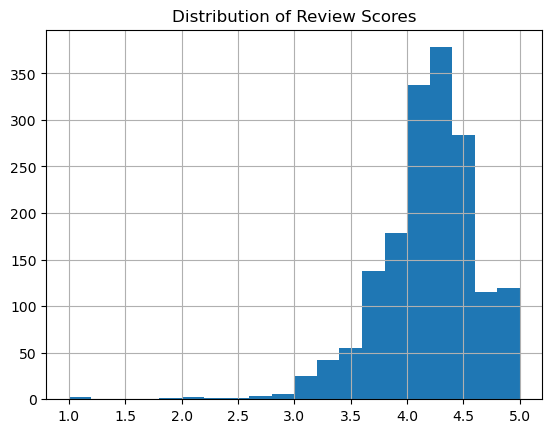

In [4]:
df["review_score"].hist(bins=20)
plt.title("Distribution of Review Scores")
plt.show()

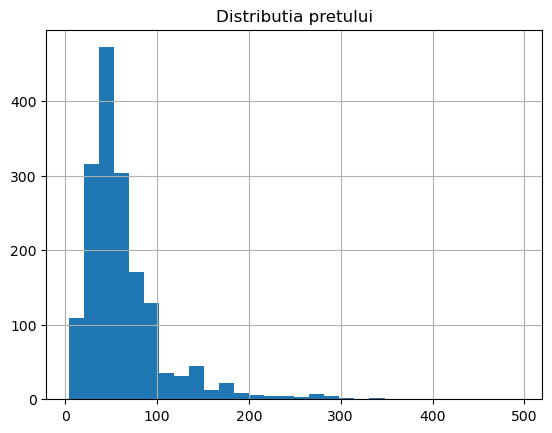

In [5]:
df["price"].hist(bins=30)
plt.title("Distributia pretului")
plt.show()

Observatii:

- Ratingurile sunt concentrate intre 4.0 si 4.5, ceea ce indica o tendinta generala
  de evaluari pozitive pentru produsele analizate.
- Pretul are o distributie asimetrica (right-skewed), cu cateva produse foarte scumpe.
- Exista potential dezechilibru daca definim o problema de clasificare.

In [6]:
import pandas as pd
import numpy as np 

df=pd.read_csv("../Data/Raw/skincare_df.csv")

if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"])

df.shape, df.columns[:10]

((1689, 47),
 Index(['Unnamed: 0', 'brand', 'name', 'price', 'n_of_reviews', 'n_of_loves',
        'review_score', 'size', 'clean_product', 'category_Anti-Aging'],
       dtype='object'))

In [7]:
missing_count=df.isna().sum()

missing_percent  = (missing_count / len(df)) * 100

missing_table = (
    pd.DataFrame({"missing_count": missing_count, "missing_percent": missing_percent})
      .sort_values("missing_count", ascending=False)
)

duplicate_rows=df.duplicated().sum()

missing_table.head(15), duplicate_rows

(                                   missing_count  missing_percent
 price_per_ounce                              226        13.380699
 size                                         226        13.380699
 category_Moisturizers                          0         0.000000
 category_Face_Wash_&_Cleansers                 0         0.000000
 category_Facial_Peels                          0         0.000000
 category_Foundation                            0         0.000000
 category_Hair_Oil                              0         0.000000
 category_Highlighter                           0         0.000000
 category_Holistic_Wellness                     0         0.000000
 category_Mini_Size                             0         0.000000
 category_Mists_&_Essences                      0         0.000000
 category_Moisturizer_&_Treatments              0         0.000000
 category_Night_Creams                          0         0.000000
 category_Face_Serums                           0         0.00

In [8]:
numeric_cols=df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1689.0,883.120782,518.854505,0.00,433.0000,879.0000,1326.0000,1784.0
price,1689.0,63.368620,47.576774,4.00,36.0000,50.0000,75.0000,495.0
n_of_reviews,1689.0,234.395500,474.697040,1.00,17.0000,70.0000,252.0000,7000.0
n_of_loves,1689.0,13348.523979,23352.847741,104.00,2077.0000,4972.0000,13022.0000,235409.0
review_score,1689.0,4.184594,0.444514,1.00,3.9571,4.2222,4.4573,5.0
size,1463.0,1.902269,2.081565,0.08,1.0000,1.6000,1.7000,32.0
clean_product,1689.0,0.190645,0.392926,0.00,0.0000,0.0000,0.0000,1.0
category_Anti-Aging,1689.0,0.014802,0.120794,0.00,0.0000,0.0000,0.0000,1.0
category_BB_&_CC_Cream,1689.0,0.020722,0.142495,0.00,0.0000,0.0000,0.0000,1.0
category_Bath_&_Shower,1689.0,0.000592,0.024332,0.00,0.0000,0.0000,0.0000,1.0


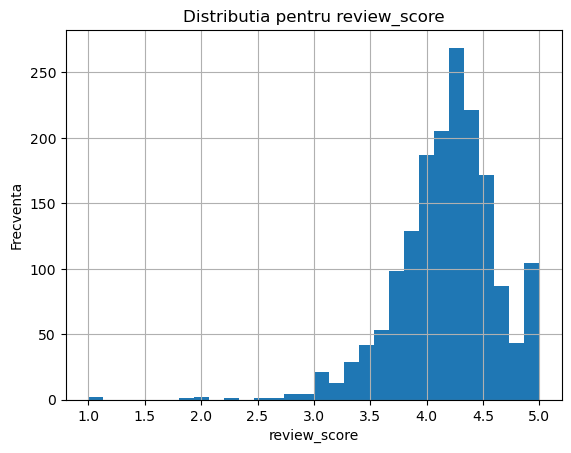

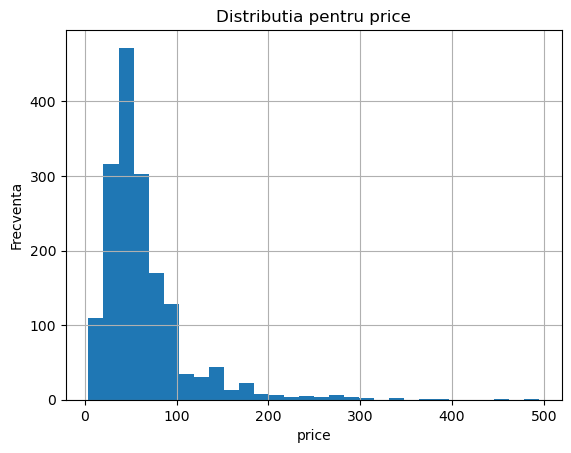

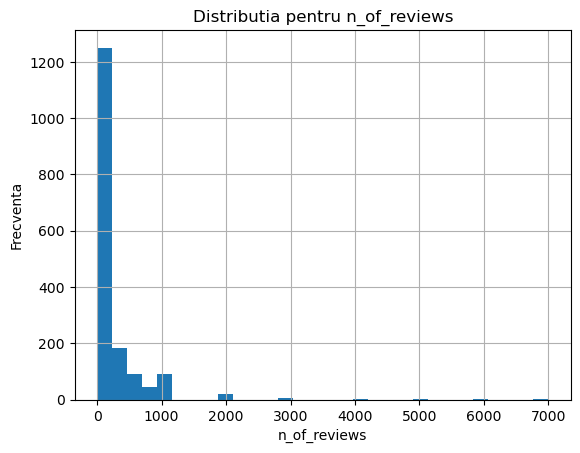

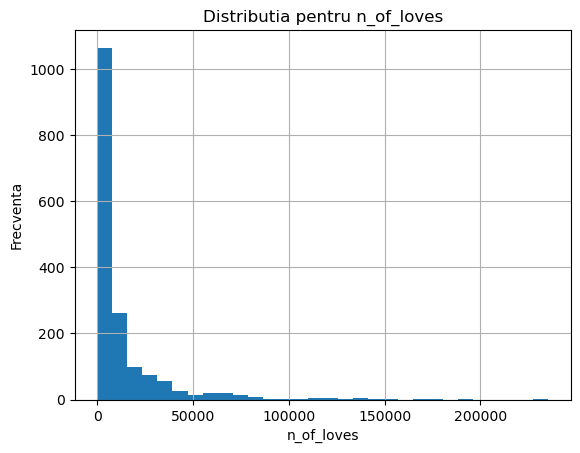

In [10]:
import matplotlib.pyplot as plt

cols_to_plot = ["review_score", "price", "n_of_reviews", "n_of_loves"]

for col in cols_to_plot:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distributia pentru {col}")
    plt.xlabel(col)
    plt.ylabel("Frecventa")
    plt.show()


In [11]:
df_eda=df.copy()

df_eda["size"]=df_eda["size"].fillna(df_eda["size"].median())
df_eda["price_per_ounce"]=df_eda["price_per_ounce"].fillna(df_eda["price_per_ounce"].median())

df_eda["log_reviews"]=np.log1p(df_eda["n_of_reviews"])
df_eda["log_loves"]=np.log1p(df_eda["n_of_loves"])

def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

df_eda["score_rating"]=minmax(df_eda["review_score"])
df_eda["score_reviews"]=minmax(df_eda["log_reviews"])
df_eda["score_loves"]=minmax(df_eda["log_loves"])
df_eda["score_price"]=1 - minmax(df_eda["price_per_ounce"])

df_eda["ScorFinal"]=100* (
    0.50 * df_eda["score_rating"] +
    0.20 * df_eda["score_reviews"] +
    0.20 * df_eda["score_loves"] +
    0.10 * df_eda["score_price"]
)

df_eda[["brand","name","review_score","n_of_reviews","n_of_loves","price","ScorFinal"]].head()

,brand,name,review_score,n_of_reviews,n_of_loves,price,ScorFinal
0,Drunk Elephant,Protini Polypeptide Moisturizer,4.2097,1000,136008,68.0,83.185031
1,La Mer,Crreme de la Mer,4.0974,493,61648,175.0,75.400254
2,IT Cosmetics,CC+ Cream with SPF 50+,4.0403,2000,188389,39.0,83.689270
3,Tatcha,The Water Cream,4.2447,1000,149323,68.0,83.869275
4,SK-II,Facial Treatment Essence,4.0622,788,68880,179.0,78.960425


In [12]:
df_eda["ScorFinal"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])

threshold = df_eda["ScorFinal"].quantile(0.75)
df_eda["Merita"] = (df_eda["ScorFinal"] >= threshold).astype(int)

threshold, df_eda["Merita"].value_counts()


(73.68169298824643,
 Merita
 0    1266
 1     423
 Name: count, dtype: int64)